# Crop Yield Prediction Using Deep Learning

This notebook presents a standalone **Deep Learning** pipeline for crop yield prediction. It uses the same dataset and temporal evaluation strategy as the preceding machine-learning workflow, while replacing conventional categorical encoding with learned **Embedding layers** inside a neural network.

### Workflow Overview
1. Environment and data preparation
2. Feature preprocessing and leakage prevention
3. Embedding-based neural network construction
4. Time-aware validation and training
5. Final training on the complete training period
6. Evaluation against the existing machine-learning models
7. Optional multi-seed ensemble
8. Analysis of learned crop embeddings
9. Model persistence and inference

> **Note:** This is a standalone notebook. Run the cells in order from top to bottom. The Bootstrap section prepares the shared data objects and evaluation utilities used throughout the notebook.


## 0. Bootstrap: Data Loading and Evaluation Setup

This section initializes the standalone workflow and prepares the objects required by the remaining sections. It handles data loading, duplicate removal, the time-based train/test split, and the evaluation function used to compare model performance.

Run this section first. If the Kaggle download is unavailable, the workflow can fall back to a local `yield_df.csv` file uploaded to the Colab environment.


In [1]:
# Core imports and reproducibility settings
# The workflow supports both KaggleHub download and a local CSV fallback.
# The target is crop yield in hg/ha, with years up to 2008 used for training.

import os, sys, subprocess, warnings
warnings.filterwarnings('ignore')
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'kagglehub'])

import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

RANDOM_STATE = 42
TARGET = 'hg/ha_yield'
TRAIN_END_YEAR = 2008

try:
    import kagglehub
    path = kagglehub.dataset_download('patelris/crop-yield-prediction-dataset')
    csv_path = os.path.join(path, 'yield_df.csv')
except Exception as e:
    print('kagglehub not available, using local file. Reason:', e)
    csv_path = 'yield_df.csv'

df = pd.read_csv(csv_path)
if 'Unnamed: 0' in df.columns:
    df.drop(columns=['Unnamed: 0'], inplace=True)
df.columns = df.columns.str.strip()
df = df.drop_duplicates().reset_index(drop=True)
assert df.duplicated().sum() == 0

df['Area_Item'] = df['Area'] + '_' + df['Item']
FEATURES = ['Area', 'Item', 'Area_Item', 'Year',
            'average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp']

train_df = df[df['Year'] <= TRAIN_END_YEAR]
test_df  = df[df['Year'] >  TRAIN_END_YEAR]
X_train, y_train = train_df[FEATURES], train_df[TARGET]
X_test,  y_test  = test_df[FEATURES],  test_df[TARGET]
print(f"Train: {len(train_df)} | Test: {len(test_df)} | Shape: {df.shape}")

def evaluate(name, model, X, y):
    pred = np.clip(model.predict(X), 0, None)
    mae  = mean_absolute_error(y, pred)
    return {
        'Model': name,
        'R2': round(r2_score(y, pred), 4),
        'R2 (log scale)': round(r2_score(np.log1p(y), np.log1p(pred)), 4),
        'MAE (hg/ha)': round(mae, 0),
        'MAE (t/ha)': round(mae / 10000, 2),
        'RMSE (hg/ha)': round(float(np.sqrt(mean_squared_error(y, pred))), 0),
    }

# لو شغّلت ده جوه النوتبوك الأصلي، results_df بتاع الـ ML موجود. لو لا، بنبدأ بجدول فاضي.
try:
    results_df
except NameError:
    results_df = pd.DataFrame()

100%|██████████| 959k/959k [00:00<00:00, 1.36MB/s]

Extracting files...
Train: 20182 | Test: 5750 | Shape: (25932, 8)


## 1. Environment and Library Setup

The required Python libraries are imported and the TensorFlow random seed is fixed to improve reproducibility. The section also reports the installed TensorFlow version and whether a GPU is available for model training.


In [5]:
# Visualization, model persistence, TensorFlow, and preprocessing utilities.
# Setting the random seed makes TensorFlow initialization and training more reproducible.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import StandardScaler

tf.keras.utils.set_random_seed(RANDOM_STATE)
print("TensorFlow", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow 2.21.0
GPU: []


## 2. Data Preprocessing for the Neural Network

The preprocessing pipeline is designed specifically for the neural network architecture and is fitted using training data only. This prevents information from the validation or test periods from influencing the learned preprocessing parameters.

### Categorical Features
- `Area`, `Item`, and `Area_Item` are converted to integer indices.
- Index `0` is reserved for previously unseen categories (`unknown`).
- These indices are subsequently mapped to learned embedding vectors.

### Numerical Features
- `Year`, rainfall, and average temperature are used as numerical inputs.
- `pesticides_tonnes` is transformed using `log1p` before scaling.
- The resulting numerical features are standardized using `StandardScaler`.

### Target Transformation
- The target `hg/ha_yield` is transformed using `log1p`.
- The transformed target is then standardized to support stable neural-network training.

### Leakage Prevention
All vocabulary mappings, scaling parameters, and target statistics are learned from the relevant training data only.


In [6]:
# Define categorical and numerical inputs used by the neural network.
# Categorical variables are represented by learned embeddings instead of one-hot encoding.
# Numerical variables are standardized, while the target is transformed to a normalized log scale.

CAT_COLS = ['Area', 'Item', 'Area_Item']
DL_NUM   = ['Year', 'average_rain_fall_mm_per_year', 'avg_temp']   # + log1p(pesticides) => 4 numeric features
N_NUM    = len(DL_NUM) + 1

def _num_matrix(frame):
    return np.column_stack([frame[DL_NUM].values.astype('float64'),
                            np.log1p(frame['pesticides_tonnes'].values)])

def fit_prep(frame):
    """يتعلم الـ vocab والـ scaler والـ target stats من frame واحد بس (الـ train)."""
    y = np.log1p(frame[TARGET].values)
    return {
        'scaler': StandardScaler().fit(_num_matrix(frame)),
        'vocabs': {c: {v: i + 1 for i, v in enumerate(sorted(frame[c].unique()))} for c in CAT_COLS},
        'y_mean': float(y.mean()),
        'y_std':  float(y.std()),
    }

def transform_X(frame, prep):
    X = {f'{c}_in': frame[c].map(prep['vocabs'][c]).fillna(0).astype('int32').values.reshape(-1, 1)
         for c in CAT_COLS}                                   # 0 = unknown category
    X['num_in'] = prep['scaler'].transform(_num_matrix(frame)).astype('float32')
    return X

def transform_y(y, prep):
    return ((np.log1p(np.asarray(y, dtype='float64')) - prep['y_mean']) / prep['y_std']).astype('float32')

def inverse_y(z, prep):
    return np.expm1(np.asarray(z, dtype='float64') * prep['y_std'] + prep['y_mean'])

# Validation = آخر سنتين في الـ train (برضه time-based، مش random)
VAL_START = TRAIN_END_YEAR - 1
fit_df = train_df[train_df['Year'] <  VAL_START]
val_df = train_df[train_df['Year'] >= VAL_START]
print(f"fit: {len(fit_df)} rows | val: {len(val_df)} rows | test: {len(test_df)} rows")

fit: 17884 rows | val: 2298 rows | test: 5750 rows


## 3. Deep Learning Model Architecture

The model combines learned categorical representations with standardized numerical features. Instead of representing each category as a sparse one-hot vector or using target encoding, the network learns a dense vector representation for each `Area`, `Item`, and `Area_Item` category.

The embedding outputs are concatenated with the numerical features and passed through a multilayer perceptron (MLP) with progressively smaller dense layers. Batch normalization, ReLU activation, and dropout are used within the hidden layers, followed by a single output neuron for the transformed yield prediction.


In [7]:
# Embedding dimensions control the size of the learned representation for each categorical feature.
# The model combines categorical embeddings with standardized numerical features.
# Three Dense layers with Batch Normalization, ReLU activation, and Dropout form the MLP.

EMB_DIMS = {'Area': 8, 'Item': 4, 'Area_Item': 16}

def build_model(prep, dropout=0.3, lr=1e-3):
    inputs, embs = [], []
    for c in CAT_COLS:
        inp = layers.Input(shape=(1,), dtype='int32', name=f'{c}_in')
        e = layers.Embedding(input_dim=len(prep['vocabs'][c]) + 1,   # +1 للـ unknown
                             output_dim=EMB_DIMS[c], name=f'emb_{c}')(inp)
        embs.append(layers.Flatten()(e))
        inputs.append(inp)

    num_in = layers.Input(shape=(N_NUM,), name='num_in')
    inputs.append(num_in)

    x = layers.Concatenate()(embs + [num_in])
    for units in (256, 128, 64):
        x = layers.Dense(units, kernel_initializer='he_normal')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation('relu')(x)
        x = layers.Dropout(dropout)(x)
    out = layers.Dense(1, name='log_yield_z')(x)

    model = keras.Model(inputs, out)
    model.compile(optimizer=keras.optimizers.Adam(lr), loss=keras.losses.Huber(delta=1.0),
                  metrics=[keras.metrics.MeanAbsoluteError(name='mae')])
    return model

prep_tmp = fit_prep(fit_df)
build_model(prep_tmp).summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Area_in             │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Item_in             │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Area_Item_in        │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_Area            │ (None, 1, 8)      │        808 │ Area_in[0][0]     │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_Item            │ (None, 1, 4)      │         44 │ Item_in[0][0]     │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_Area_Item       │ (None, 1, 16)     │      9,424 │ Area_Item_in[0][… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 8)         │          0 │ emb_Area[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 4)         │          0 │ emb_Item[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_2 (Flatten) │ (None, 16)        │          0 │ emb_Area_Item[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ num_in (InputLayer) │ (None, 4)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 32)        │          0 │ flatten[0][0],    │
│ (Concatenate)       │                   │            │ flatten_1[0][0],  │
│                     │                   │            │ flatten_2[0][0],  │
│                     │                   │            │ num_in[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │      8,448 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256)       │      1,024 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 256)       │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │     32,896 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 128)       │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 61,733 (241.14 KB)

 Trainable params: 60,837 (237.64 KB)

 Non-trainable params: 896 (3.50 KB)

## 4. Training and Time-Based Validation

The neural network is first trained using a chronological validation split. This preserves the temporal structure of the dataset and avoids randomly mixing observations from different periods.

Training uses **Early Stopping** to restore the best validation weights and **ReduceLROnPlateau** to lower the learning rate when validation loss stops improving. The epoch associated with the minimum validation loss is recorded and used to determine the training duration for the final model.

The learning curves are also plotted to provide a visual assessment of training and validation behavior.


Epoch 1/200
70/70 - 3s - 48ms/step - loss: 0.5666 - mae: 0.9555 - val_loss: 0.3486 - val_mae: 0.7028 - learning_rate: 0.0010
Epoch 2/200
70/70 - 1s - 7ms/step - loss: 0.2834 - mae: 0.6139 - val_loss: 0.1987 - val_mae: 0.5130 - learning_rate: 0.0010
Epoch 3/200
70/70 - 1s - 10ms/step - loss: 0.1752 - mae: 0.4681 - val_loss: 0.1140 - val_mae: 0.3731 - learning_rate: 0.0010
Epoch 4/200
70/70 - 1s - 10ms/step - loss: 0.1183 - mae: 0.3769 - val_loss: 0.0747 - val_mae: 0.2849 - learning_rate: 0.0010
Epoch 5/200
70/70 - 1s - 10ms/step - loss: 0.0846 - mae: 0.3153 - val_loss: 0.0521 - val_mae: 0.2336 - learning_rate: 0.0010
Epoch 6/200
70/70 - 1s - 10ms/step - loss: 0.0677 - mae: 0.2784 - val_loss: 0.0380 - val_mae: 0.1907 - learning_rate: 0.0010
Epoch 7/200
70/70 - 1s - 10ms/step - loss: 0.0569 - mae: 0.2543 - val_loss: 0.0371 - val_mae: 0.1918 - learning_rate: 0.0010
Epoch 8/200
70/70 - 1s - 9ms/step - loss: 0.0510 - mae: 0.2406 - val_loss: 0.0340 - val_mae: 0.1783 - learning_rate: 0.0010
Ep

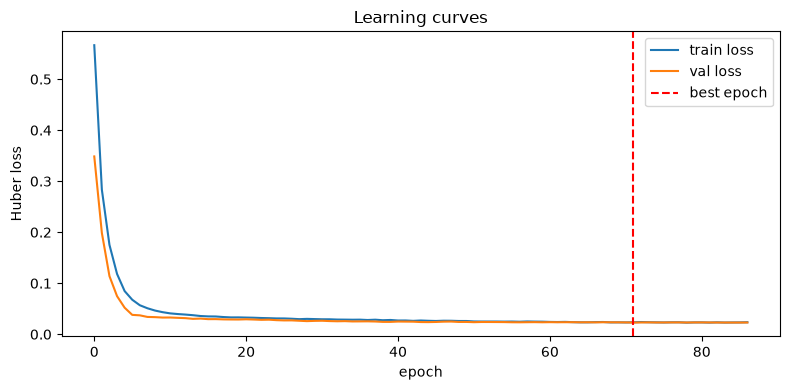

In [8]:
# Fit preprocessing only on the fitting period to avoid temporal data leakage.
# The final two training years are kept as a chronological validation period.
# Early stopping selects the best training epoch, while ReduceLROnPlateau adapts the learning rate.

prep_fit = fit_prep(fit_df)
Xf, yf = transform_X(fit_df, prep_fit), transform_y(fit_df[TARGET], prep_fit)
Xv, yv = transform_X(val_df, prep_fit), transform_y(val_df[TARGET], prep_fit)

nn = build_model(prep_fit)
callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5, verbose=1),
]
history = nn.fit(Xf, yf, validation_data=(Xv, yv),
                 epochs=200, batch_size=256, callbacks=callbacks, verbose=2)

best_epochs = int(np.argmin(history.history['val_loss'])) + 1
print("Best epoch:", best_epochs)

plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.axvline(best_epochs - 1, color='red', ls='--', label='best epoch')
plt.xlabel('epoch'); plt.ylabel('Huber loss'); plt.legend(); plt.title('Learning curves')
plt.tight_layout(); plt.show()

## 5. Final Training on the Complete Training Period

After selecting the appropriate number of epochs from the validation stage, the neural network is retrained using the complete training period (1990–2008). No separate validation subset is used during this final training stage.

The resulting model is then evaluated on the held-out test period (2009–2013), which remains completely separate from model fitting.


In [9]:
# Refit preprocessing on the complete training period after selecting the number of epochs.
# The final neural network is then trained using all observations available before the test period.
# A small wrapper exposes a sklearn-like predict interface for consistent evaluation.

prep_dl = fit_prep(train_df)
Xtr, ytr = transform_X(train_df, prep_dl), transform_y(train_df[TARGET], prep_dl)

nn_final = build_model(prep_dl)
nn_final.fit(Xtr, ytr, epochs=best_epochs, batch_size=256, verbose=0,
             callbacks=[keras.callbacks.ReduceLROnPlateau(monitor='loss', factor=0.5, patience=5, min_lr=1e-5)])

class KerasYieldModel:
    """Wrapper بيدّي نفس واجهة sklearn (predict) عشان ندخله في دالة evaluate بتاعتنا."""
    def __init__(self, model, prep): self.model, self.prep = model, prep
    def predict(self, X):
        z = self.model.predict(transform_X(X, self.prep), verbose=0).ravel()
        return inverse_y(z, self.prep)

dl_model = KerasYieldModel(nn_final, prep_dl)
print("Done.")

Done.


## 6. Performance Comparison with the Machine-Learning Models

The trained neural network is evaluated using the same test observations and evaluation function used for the existing machine-learning models. The results are then combined into a single table so that the Deep Learning model can be examined under the same evaluation conditions as the baseline models.

The comparison includes the reported evaluation metrics, including **R²**, MAE, and RMSE where available in the shared evaluation output.


In [10]:
# Evaluate the neural network on the same held-out test period used by the other models.
# Keeping the evaluation function unchanged makes the model comparison consistent.

dl_row = evaluate('Neural Network (Embeddings)', dl_model, X_test, y_test)
results_all = (pd.concat([results_df, pd.DataFrame([dl_row])], ignore_index=True)
                 .sort_values('R2', ascending=False).reset_index(drop=True))
display(results_all)

,Model,R2,R2 (log scale),MAE (hg/ha),MAE (t/ha),RMSE (hg/ha)
0,Neural Network (Embeddings),0.9541,0.9499,10438.0,1.04,20317.0


## 7. Optional Multi-Seed Ensemble

Neural-network training can produce slightly different results under different random seeds. This optional section trains five instances of the same architecture using different seeds and averages their predictions.

The ensemble is evaluated on the same test period and added to the comparison table. Its purpose is to examine whether averaging multiple independently trained networks provides more stable predictions.


In [11]:
# Train multiple neural networks with different random seeds to reduce sensitivity to initialization.
# The ensemble averages predictions from the five independently trained networks.

def train_one(seed):
    tf.keras.utils.set_random_seed(seed)
    m = build_model(prep_dl)
    m.fit(Xtr, ytr, epochs=best_epochs, batch_size=256, verbose=0,
          callbacks=[keras.callbacks.ReduceLROnPlateau(monitor='loss', factor=0.5, patience=5, min_lr=1e-5)])
    return m

class EnsembleYieldModel:
    def __init__(self, models, prep): self.models, self.prep = models, prep
    def predict(self, X):
        Xt = transform_X(X, self.prep)
        z = np.mean([m.predict(Xt, verbose=0).ravel() for m in self.models], axis=0)
        return inverse_y(z, self.prep)

ensemble = EnsembleYieldModel([train_one(s) for s in range(5)], prep_dl)
ens_row = evaluate('Neural Network (5-seed ensemble)', ensemble, X_test, y_test)
results_all = (pd.concat([results_all, pd.DataFrame([ens_row])], ignore_index=True)
                 .sort_values('R2', ascending=False).reset_index(drop=True))
display(results_all)

,Model,R2,R2 (log scale),MAE (hg/ha),MAE (t/ha),RMSE (hg/ha)
0,Neural Network (Embeddings),0.9541,0.9499,10438.0,1.04,20317.0
1,Neural Network (5-seed ensemble),0.9532,0.9527,10430.0,1.04,20513.0


## 8. Analysis of Learned Embeddings

One advantage of the embedding-based architecture is that the model learns continuous representations of categorical values during training. This section extracts the learned `Item` embeddings and projects them into two dimensions using **Principal Component Analysis (PCA)**.

The resulting visualization provides a qualitative view of how crop categories are positioned in the learned representation space.


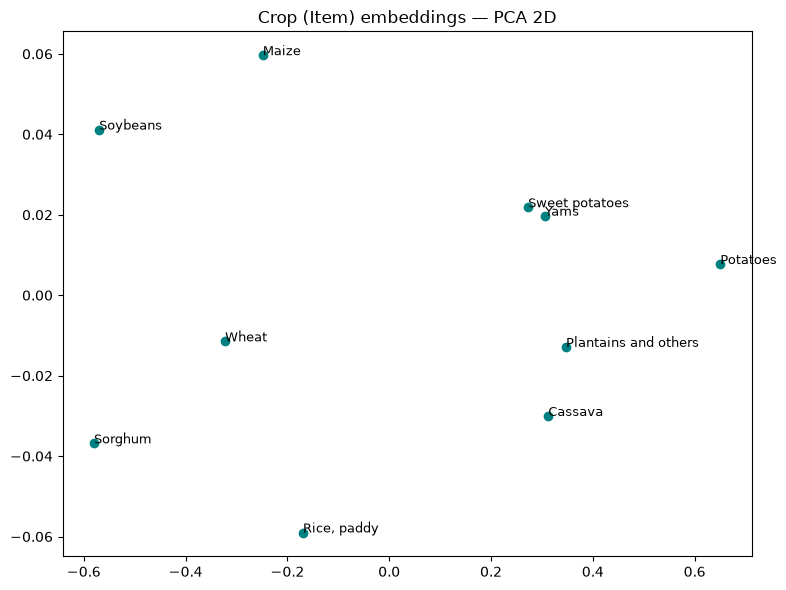

In [12]:
# Extract the learned Item embeddings and project them to two dimensions using PCA.
# This provides a visual inspection of how the network represents different crop categories.

from sklearn.decomposition import PCA

emb = nn_final.get_layer('emb_Item').get_weights()[0][1:]          # شيل صف الـ unknown
items = [k for k, _ in sorted(prep_dl['vocabs']['Item'].items(), key=lambda kv: kv[1])]
xy = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(emb)

plt.figure(figsize=(8, 6))
plt.scatter(xy[:, 0], xy[:, 1], color='teal')
for (x, y), name in zip(xy, items):
    plt.annotate(name, (x, y), fontsize=9)
plt.title('Crop (Item) embeddings — PCA 2D'); plt.tight_layout(); plt.show()

## 9. Model Persistence and Inference

The final trained neural network and its preprocessing information are saved for later reuse. The saved preprocessing object contains the learned vocabularies, scaling information, model features, and selected number of training epochs.

A prediction function is also provided to demonstrate inference on a new combination of area, crop, year, rainfall, pesticide usage, and temperature. The returned prediction is reported both in `hg/ha` and converted to `t/ha`.


In [13]:
# Save the trained neural network and preprocessing artifacts for later inference.
# The prediction function prepares a single input row using the same feature structure as training.

nn_final.save('crop_yield_nn.keras')
joblib.dump({'prep': prep_dl, 'features': FEATURES, 'best_epochs': best_epochs}, 'crop_yield_nn_prep.joblib')

def predict_crop_yield_nn(area, item, year, rain_fall, pesticides, temp, model=dl_model):
    row = pd.DataFrame([{
        'Area': area, 'Item': item, 'Area_Item': f'{area}_{item}', 'Year': year,
        'average_rain_fall_mm_per_year': rain_fall, 'pesticides_tonnes': pesticides, 'avg_temp': temp,
    }])
    pred = float(np.clip(model.predict(row)[0], 0, None))
    return {'hg_per_ha': round(pred, 1), 't_per_ha': round(pred / 10000, 3)}

predict_crop_yield_nn('Albania', 'Maize', 2013, 1485.0, 121.0, 16.37)

{'hg_per_ha': 54868.6, 't_per_ha': 5.487}